<a href="https://colab.research.google.com/github/iliaxant/Pattern_Recognition_Final_Project/blob/main/Final_Project_PR_58545.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Τελική Εργασία Εξαμήνου**

## Αναγνώριση Προτύπων - Ακαδημαϊκό έτος 2025-2026

## Ηλίας Ξανθόπουλος 58545

## GitHub Repo: https://github.com/iliaxant/Pattern_Recognition_Final_Project

---

## **Set-Up**

1) Χειροκίνητο ανέβασμα του αρχείου *Final_Project_data.zip*.

2) Unziping του αρχείου *Final_Project_data.zip*:

In [1]:
import zipfile

zip_path = '/content/Final_Project_data.zip'
zip_ref = zipfile.ZipFile(zip_path, 'r')
zip_ref.extractall('/content')
zip_ref.close()

print("Data unzipped successfully to /content directory.")

Data unzipped successfully to /content directory.


3) Εγκατάσταση και φόρτωση των απαραίτητων βιβλιοθηκών.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns
import random
import h5py
from scipy.stats import randint, uniform, reciprocal

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, RandomizedSearchCV,
                                     GridSearchCV, PredefinedSplit)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_recall_curve, classification_report
from sklearn.metrics import (accuracy_score, recall_score, roc_auc_score,
                             precision_score, f1_score, average_precision_score)

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

4) Ορισμός συνάρτησης αρχικοποίησης όλων των χρησιμοποιούμενων random state machines για reproducibility.

In [4]:
def set_seed(seed=15):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

---

## **Μέρος 1ο – Ανίχνευση Αστοχίας σε Βιομηχανική Διαδικασία**

Αρχικοποίηση των random state machines με το seed '15'.

In [5]:
state = 15
set_seed(state)

print(f"Seed '{state}' has been set.")

Seed '15' has been set.


### **Α) Επισκόπηση Δεδομένων**


Ορισμός συνάρτησης ανάλυσης δεδομένων ενός dataframe.

Η συνάρτηση **dataframe_analysis()** δέχεται ως παραμέτρους εισόδου:

*   **df:** το pandas dataframe προς ανάλυση.
*   **label_flag=False:** σημαία που δηλώνει αν υπάρχει στήλη ετικετών στο dataframe.
*   **label_col_name=' '** string που αντιστοιχεί στο όνομα της στήλης ετικετών,εφόσον υπάρχει.

Οι πληροφορίες που δίνει η συνάρτηση για τα δεδομένα αφορούν:

*   Αναλογία των κλάσεων (εφόσον label_flag=Τrue)
*   Missing Values
*   Διπλότυπα δείγματα
*   Features με σταθερή τιμή
*   Features με σχεδόν σταθερή τιμή (πλήθος σταθερών τιμών ίσο ή μεγαλύτερο του 99% των δειγμάτων)

In [ ]:
def dataframe_analysis(df, label_flag=False, label_col_name=''):

    print(df.info())

    if label_flag:
        print('\n' + 15 * "-" + " Class Info " + 15 * "-" + '\n')
        print(df[label_col_name].value_counts())
        print()
        print(df[label_col_name].value_counts(normalize=True).map('{:.1%}'.format))
        print('\n' + 42 * "-")


    print('\n' + 15 * "-" + " Missing Values " + 15 * "-" + '\n')

    missing_per_feat = df.isnull().sum()
    missing_per_sample = df.isnull().sum(axis=1)

    missing_per_feat_percent = (df.isnull().mean() * 100).round(2)
    missing_per_sample_percent = (df.isnull().mean(axis=1) * 100).round(2)

    missing_feat_table = pd.DataFrame({
        'Missing Count': missing_per_feat,
        'Percent (%)': missing_per_feat_percent
    })

    missing_sample_table = pd.DataFrame({
        'Missing Count': missing_per_sample,
        'Percent (%)': missing_per_sample_percent
    })

    if label_flag and label_col_name in df.columns:
        missing_sample_table['Class'] = df[label_col_name]

    missing_feat_table = missing_feat_table.sort_values(by='Percent (%)', ascending=False)
    missing_sample_table = missing_sample_table.sort_values(by='Percent (%)', ascending=False)


    print(f'Missing Values per Feature Table (Descending):')
    print(missing_feat_table)
    print()

    print(f'Τop 20 Missing Values per Feat Table:')
    print(missing_feat_table.head(20))
    print()

    print(f'Missing Values per Sample Table (Descending):')
    print(missing_sample_table)
    print()

    print(f'Τop 20 Missing Values per Sample Table:')
    print(missing_sample_table.head(20))
    print()

    if label_flag:

        classes = df[label_col_name].unique()
        for cls in sorted(classes):

            class_subset = df[df[label_col_name] == cls]
            total_missing_class = class_subset.isnull().sum().sum()
            total_cells_class = class_subset.size
            percent_missing_class = (total_missing_class / total_cells_class) * 100

            print(f"Missing values of Class {cls}: {total_missing_class} / {total_cells_class} "
                  f"-> {percent_missing_class:.2f}%")


    total_cells = df.size
    total_missing = missing_per_feat.sum()
    percent_missing = (total_missing / total_cells) * 100

    print(f"\nMissing values of set: {total_missing} / {total_cells} "
          f"-> {percent_missing:.2f}%")

    print('\n' + 46 * "-")


    print('\n' + 15 * "-" + " Duplicates " + 15 * "-" + '\n')
    dupes = df.duplicated()
    print(f'Dublicates List:')
    print(dupes)

    print(f"\nTotal dublicate samples: {dupes.sum()}")
    print('\n' + 42 * "-")


    print('\n' + 15 * "-" + " Constant Features " + 15 * "-" + '\n')
    constant_feat = [feat for feat in df.columns if df[feat].nunique() <= 1]
    print(f"Constant Features List: {constant_feat}")
    print(f'\nTotal constant features: {len(constant_feat)}')
    print('\n' + 48 * "-")


    print('\n' + 15 * "-" + " Quasi-Constant Features " + 15 * "-" + '\n')

    quasi_constant_feats = []
    for feat in df.columns:

        if (feat == label_col_name) or (feat in constant_feat): continue

        top_val_freq = df[feat].value_counts(normalize=True, dropna=False).values[0]

        if top_val_freq >= 0.99:
            quasi_constant_feats.append(feat)

    print(f"Quasi-Constant (>=99% but not 100% of values) Feature List: {quasi_constant_feats}")
    print(f'\nTotal quasi-constant features: {len(quasi_constant_feats)}')

    print('\n' + 55 * "-")



Φόρτωση των training δεδομένων (*Training_data_manifacturing.csv* αρχείο). Ονομασία της κάθε στήλης (καθαρά προαιρετικό) και εκτύπωση χρήσιμων πληροφοριών για τα training δεδομένα μέσω της **dataframe_analysis()**.

In [ ]:
columns = [f"Feat {i}" for i in range(474)] + ["y"]

class_column = columns[-1]
data_columns = columns[0:474]

df_train = pd.read_csv("Training_data_manifacturing.csv", header=None, names=columns)

print('\n' + 25 * "=" + " Training Data " + 25 * "=" + '\n')
dataframe_analysis(df_train, 1, class_column)
print('\n' + 65 * "=" + '\n\n')



========================= Training Data =========================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Columns: 475 entries, Feat 0 to y
dtypes: float64(474), int64(1)
memory usage: 4.5 MB
None

--------------- Class Info ---------------

y
0    1170
1      84
Name: count, dtype: int64

y
0    93.3%
1     6.7%
Name: proportion, dtype: object

------------------------------------------

--------------- Missing Values ---------------

Missing Values per Feature Table (Descending):
          Missing Count  Percent (%)
Feat 148           1153        91.95
Feat 247           1153        91.95
Feat 149           1153        91.95
Feat 248           1153        91.95
Feat 401           1077        85.89
...                 ...          ...
Feat 418              0         0.00
Feat 459              0         0.00
Feat 417              0         0.00
Feat 18               0         0.00
y                     0         0.00

[475 rows x 2 columns]

Τop 20 M

Φόρτωση των testing δεδομένων (*Test_data_manifacturing.csv* αρχείο) και εκτύπωση χρήσιμων πληροφοριών για τα δεδομένα μέσω της **dataframe_analysis()**.

**ΣΧΟΛΙΟ:** Αν και εφαρμόζεται η συνάρτηση επισκόπησης και στα testing δεδομένα, παρακάτω δεν πρέπει γίνει καμία επεξεργασία σε οποιοδήποτε από τα set με βάση τις πληροφορίες που δίνει η συνάρτηση για τα testing δεδομένα. Ό,τι επεξεργασία ακολουθήσει πάνω στα training και testing δεδομένα πρέπει να γίνει με γνώμονα **ΜΟΝΟ** το training set. Η χρήση της συνάρτησης επισκόπησης στα testing δεδομένα γίνεται καθαρά για την κατανόηση του προβλήματος προς επίλυση.

In [ ]:
df_test = pd.read_csv("Test_data_manifacturing.csv", header=None, names=data_columns)

print('\n' + 25 * "=" + " Testing Data " + 25 * "=" + '\n')
dataframe_analysis(df_test)
print('\n' + 64 * "=" + '\n\n')



========================= Testing Data =========================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Columns: 474 entries, Feat 0 to Feat 473
dtypes: float64(473), int64(1)
memory usage: 1.1 MB
None

--------------- Missing Values ---------------

Missing Values per Feature Table (Descending):
          Missing Count  Percent (%)
Feat 248            276        88.18
Feat 247            276        88.18
Feat 149            276        88.18
Feat 148            276        88.18
Feat 401            264        84.35
...                 ...          ...
Feat 469              0         0.00
Feat 470              0         0.00
Feat 471              0         0.00
Feat 472              0         0.00
Feat 473              0         0.00

[474 rows x 2 columns]

Τop 20 Missing Values per Feat Table:
          Missing Count  Percent (%)
Feat 248            276        88.18
Feat 247            276        88.18
Feat 149            276        88.18
Feat 148    

Παρατηρούνται δύο πολύ σημαντικά προβλήματα στα δεδομένα.

Το πρώτο είναι τα missing values. Τόσο στα training όσο και στα testing δεδομένα υπάρχει ένα ποσοστό ~5.54% των κελιών το οποίο δεν έχει καθόλου τιμή. Αν και φαίνεται αρκετά μικρό το ποσοστό, οι missing τιμές είναι συγκεντρωμένες σε υψηλά ποσοστά σε συγκεκριμένα χαρακτηριστικά, με κάποια από αυτά να φτάνουν missing ποσοστά εώς και 91.95% στο training και 88.18% στο testing. Παρόλα αυτά, όπως φαίνεται και στις πληροφορίες για τα training δεδομένα, δεν υπάρχουν καθόλου NaN κελία στην στήλη των ετικετών και δεν υπάρχουν δείγματα με υπερβολικά πολλές missing τιμές, το οποίο σημαίνει ότι δεν απαραίτητο να απορριφθούν δείγματα, αλλά πρέπει οπωσδήποτε να επιλεχθεί μια στρατηγική αντιμετώπισης των missing values.

Το δεύτερο πρόβλημα αφορά την κατανομή των κλάσεων και είναι η ανισότητα. Όπως φαίνεται παραπάνω, η συντριπτική πλειοψηφία των δειγμάτων του training dataframe ανήκει στην κλάση 0 και μόνο το 6.7% των training δεδομένων αντιστοιχεί στην κλάση 1. Παρόλο που δεν υπάρχουν ετικέτες για επιβεβαίωση, είναι εκ των προτέρων γνωστό ότι παρόμοια αναλογία υπάρχει και στα testing δεδομένα. Επομένως, πρέπει να εφαρμοστούν οι κατάλληλες τεχνικές για την διαχείριση της ανισότητας κλάσεων.

Και τα δύο προβλήματα επιλύονται σε παρακάτω cells.

Επίσης σημαντική παρατήρηση είναι η ύπαρξη σχεδόν σταθερών (και σταθερών) χαρακτηριστικών στo training set. Αυτή η σταθερότητα καθιστά τα χαρακτηριστικά redundant και οδηγούν σε πιο περίπλοκους τους υπολογισμούς χωρίς κάποια πρακτική αξία. Επομένως, αυτά τα χαρακτηριστικά είναι αναγκαίο να αφαιρεθούν.

**ΣΧΟΛΙΟ:** Στα παραπάνω μηνύματα για τα δεδομένα υπάρχει ένα discrepancy ως προς τον τύπο των δεδομένων.

Παρατηρούμε ότι στα training δεδομένα όλες οι στήλες είναι float64 εκτός από την στήλη των ετικετών που είναι int64. Στα testing δεδομένα που υπάρχουν τα ίδια χαρακτηριστικά αλλά δεν υπάρχει η στήλη ετικετών, πάλι βλέπουμε όλες τις στήλες να είναι float64, εκτός από μία που είναι int64.

Αυτό εν τέλει δεν είναι τυχαίο, διότι η ύπαρξη missing τιμών σε μία στήλη αυτόματα την μετατρέπει σε τύπο δεδομένων float64. Επομένως, στην περίπτωση των training δεδομένων, όλες οι στήλες χαρακτηριστικών τύπου int64 έχουν NaN τιμές, οπότε μετατρέπεται η στήλη σε float64, ενώ στα testing δεδομένα υπάρχει μια στήλη int64 που προηγουμένως είχε missing τιμές, αλλά τώρα δεν έχει, οπότε παραμένει int64.

Αυτό επιβεβαιώνεται τόσο από το παρακάτω code cell, όσο και από μια γρήγορη επισκόπηση των τιμών των δύο *.csv* αρχείων.




In [ ]:
print("*** Ignore 'dtype' lines ***\n")

int_cols_test = df_test.select_dtypes(include=['int64']).columns
print(f"Columns of int64 data type: {(list(int_cols_test))}")

print(f"\n--- Info for '{int_cols_test}' on Train data frame ---")
print(f"Data type: {df_train[int_cols_test].dtypes}")
print(f"Num of missing values: {df_train[int_cols_test].isnull().sum()}")

print(f"\n--- Info for '{int_cols_test}' on Test data frame ---")
print(f"Data type: {df_test[int_cols_test].dtypes}")
print(f"Num of missing values: {df_test[int_cols_test].isnull().sum()}")

*** Ignore 'dtype' lines ***

Columns of int64 data type: ['Feat 128']

--- Info for 'Index(['Feat 128'], dtype='object')' on Train data frame ---
Data type: Feat 128    float64
dtype: object
Num of missing values: Feat 128    5
dtype: int64

--- Info for 'Index(['Feat 128'], dtype='object')' on Test data frame ---
Data type: Feat 128    int64
dtype: object
Num of missing values: Feat 128    0
dtype: int64


### **Β) Προεπεξεργασία Δεδομένων**

Μετά από την επισκόπηση των δεδομένων ακολουθεί η προεπεξεργασία τους. Οι διαδικασίες αυτού τα σταδίου επιλέγονται με βάση της πληροφορίες που έχουν αντληθεί από την επισκόπηση και είναι οι εξής:

*   **Αφαίρεση Σταθερών και Σχεδόν Σταθερών Χαρακτηριστικών**
*   **Αφαίρεση Χαρακτηριστικών με Μεγάλο Ποσοστό Ελλειπουσών Τιμών**
*   **Συμπλήρωση Eλλειπουσών Tιμών**
*   **Standard Scaling**

Οι παραπάνω διαδικασίες εφαρμόζονται με την σειρά που παρατίθενται, αλλά απευθείας εκτελούνται μόνο οι δύο πρώτες. Οι υπόλοιπες δύο εφαρμοζονται πριν την εκπαίδευση του μοντέλου σε κάθε fold. Για αυτό και σε αυτή την ενότητα, για αυτές τις δύο διεργασίες ορίζονται μόνο οι συναρτήσεις που τις διαχειρίζονται, αφού αργότερα θα προστεθούν αυτές στο pipeline της εκπαίδευσης. Το γιατί επιλέγεται να αξιοποιηθεί k-fold cross validation και πως δομείται το pipeline εκπαίδευσης εξηγείται σε επόμενη φάση. Σε αυτή την ενότητα ορίζονται μόνο οι διαδικασίες preprocessing που εφαρμόζονται.



#### **i) Αφαίρεση Σταθερών και Σχεδόν Σταθερών Χαρακτηριστικών**




Αφαίρεση των σταθερών και των σχεδόν σταθερών (>=99% σταθερών) χαρακτηριστικών του training set, τόσο από τα training, όσο και τα testing δεδομένα. Αυτό το βήμα πρέπει να γίνει, καθώς τα σταθερά χαρακτηριστικά δεν προσφέρουν καμία πληροφορία στο μοντέλο αλλά αυξάνουν μόνο τις διαστάσεις του προβλήματος.

In [ ]:
quasi_constant_thresh = 0.99

quasi_constant_feats = []
for feat in df_train[data_columns].columns:

    top_val_freq = df_train[feat].value_counts(normalize=True, dropna=False).values[0]

    if top_val_freq >= quasi_constant_thresh:
        quasi_constant_feats.append(feat)

print(f"\nConstant / Quasi-Constant (>= {quasi_constant_thresh*100}% same value) "
      f"Feature list:")
print(quasi_constant_feats)
print(f"\nRemoving {len(quasi_constant_feats)} Constant / Quasi-Constant Features...")

df_train_const_clean = df_train.drop(columns=quasi_constant_feats)
df_test_const_clean = df_test.drop(columns=quasi_constant_feats)

print(f'\nOriginal Train shape: {df_train.shape}')
print(f'Original Test shape: {df_test.shape}')

print(f'\nTrain shape after feature removal: {df_train_const_clean.shape}')
print(f'Test shape after feature removal: {df_test_const_clean.shape}\n')



Constant / Quasi-Constant (>= 99.0% same value) Feature list:
['Feat 68', 'Feat 188', 'Feat 191', 'Feat 287', 'Feat 292', 'Feat 388']

Removing 6 Constant / Quasi-Constant Features...

Original Train shape: (1254, 475)
Original Test shape: (313, 474)

Train shape after feature removal: (1254, 469)
Test shape after feature removal: (313, 468)



#### **ii) Αφαίρεση Χαρακτηριστικών με Μεγάλο Ποσοστό Ελλειπουσών Τιμών**

Χαρακτηριστικά του training set με μεγάλο ποσοστό missing τιμών (>=80%) πρέπει να αφαιρεθούν από το training και testing set γιατί δεν είναι εφικτό να συμπληρωθούν τα κενά χωρίς βλάβη της γενικότητας και η μείωση των διαστάσεων προσφέρει στην συγκεκριμένη περίπτωση μεγαλύτερη αξία. Προτού όμως απομακρυνθούν αυτές οι στήλες είναι απαραίτητο να προσδιοριστεί εάν αυτές οι missing τιμές συσχετίζονται περισσότερο με μία από τις δύο κλάσεις, που σημαίνει ότι αυτό το υψηλό ποσοστό missing προσφέρει χρήσιμες για το μοντέλο πληροφορίες. Αυτή η κατηγορία missing data ονομάζεται **MNAR** και εάν το feature δεν ανήκει σε αυτή την κατηγορία, τότε μπορεί να αφαιρεθεί από τα δεδομένα.

Εκτός από την κατηγορία **MNAR** υπάρχουν και άλλες δύο κατηγορίες missing data και κάθε μία από αυτές απαιτεί διαφορετική διαχείρηση. Για αρχή, οι τρεις τύποι είναι:

*   **Missing Completely At Random (MCAR):** Σε αυτήν την περίπτωση, η πιθανότητα έλλειψης των δεδομένων είναι ανεξάρτητη από τις αντίστοιχες τιμές (παρατηρούμενες ή μη) των χαρακτηριστικών. Για παράδειγμα, στην παρούσα εφαρμογή θα μπορούσε να ήταν missing τιμές λόγω στιγμιαίων διακοπών ρεύματος στους αισθητήρες, κάτι που οφείλεται σε έναν εξωγενή και τελείως τυχαίο παράγοντα.

*   **Missing At Random (MAR):** Εδώ οι missing τιμές χαρακτηριστικών οφείλονται στις μετρούμενες τιμές άλλων χαρακτηριστικών. Κάτι τέτοιο ισχύει όταν, για παράδειγμα, ένας αισθήτηρας σταματάει να καταγράφει τιμές (άρα missing value), όταν ένας άλλος αισθητήρας καταγράφει πάρα πολύ υψηλή τιμή ενός άλλου μεγέθους. Σε αυτήν την περίπτωση, τα ελλειπή δεδομένα δεν οφείλονται στην ίδια την τιμή που κανονικά θα παρατηρούταν, αλλά σε άλλα χαρακτηριστικά για τα οποία έχει καταγραφεί τιμή.

*   **Missing Not At Random (MNAR):** Η έλλειψη τιμής οφείλεται στην ίδια τιμή που λείπει. Εδώ η αιτία δεν είναι καθόλου τυχαία, αλλά εξαρτάται από την ίδια την φύση του μετρούμενου μεγέθους. Στην συγκεκριμένη εφαρμογή, θα μπορούσε να υπάρχει αυτός ο τύπος, εάν ένας αισθητήρας παύει να λειτουργεί, όταν η μετρούμενη τιμή ξεπερνάει ένα όριο.

Από αυτές τις τρείς κατηγορίες, η πιο διαχειρίσιμη είναι η πρώτη, καθώς είναι εντελώς τυχαία, ενώ πιο επικίνδυνη είναι η τρίτη, διότι μπορεί να φανερώνει πληροφορίες για τις τάξεις που προσπαθούμε να διαχωρίσουμε. Κάθε τύπος απαιτεί διαφορετική τεχνική αντιμετώπισης, επομένως πρέπει να προσδιοριστεί ο τύπος των ελλειπουσών τιμών.

Όπως προαναφέρθηκε, πρώτη διαδικασία διαχείρησης missing data είναι η απομάκρυνση των features με υψηλό ποσοστό ελλειπών τιμών **εφόσον** δεν ανήκουν αυτές στην κατηγορία **MNAR**. Για να το ελέγξουμε αυτό βρίσκουμε την συσχέτιση του συγκεκριμένου χαρακτηριστικού με την έξοδο. Αν σε μια από τις δύο κλάσεις υπάρχουν πολύ περισσότερα missing values απ' ότι στην άλλη, τότε είναι πολύ πιθανόν το χαρακτηριστικό να μην έχει **MCAR** τιμές αλλά **MNAR** (ή τουλάχιστον **MAR**) και επομένως να μην πρέπει να απομακρυνθεί.

Εύρεση των χαρακτηριστικών με missing data >=80% στο training set. Έλεγχος κάθε εντοπισμένου χαρακτηριστικού για το αν τα missing δεδομένα του ανήκουν στην κατηγορία **NMAR** συγκρίνοντας τα ποσοστά missing data μεταξύ των κλάσεων. Αν η διαφορά μεταξύ των δύο ποσοστών είναι <20%, τότε το χαρακτηριστικό αφαιρείται από τα training και testing δεδομένα, διαφορετικά διατηρείται.

In [ ]:
missing_thresh = 0.80
missing_diff_thresh = 0.10

limit = missing_thresh * len(df_train_const_clean)
high_missing_feats = df_train_const_clean.columns[df_train_const_clean.isnull().sum() > limit].tolist()

print(f"\nMissing >={missing_thresh*100}% of values Feature list:")
print(high_missing_feats)


print('\n' + 10 * "-" + " MNAR Check " + 10 * "-" + '\n')

idx_0 = df_train_const_clean['y'] == 0
idx_1 = df_train_const_clean['y'] == 1

suspicious_feats = []

for feat in high_missing_feats:

    missing_rate_0 = df_train_const_clean.loc[idx_0, feat].isnull().mean()
    missing_rate_1 = df_train_const_clean.loc[idx_1, feat].isnull().mean()

    diff = missing_rate_1 - missing_rate_0
    print(f"{feat:<8}: Missing Rate Class 0(-) = {missing_rate_0:>6.2%} | Class 1(+) = {missing_rate_1:>6.2%} "
          f"| Diff = {diff:>7.2%}")

    if diff > missing_diff_thresh:
        suspicious_feats.append(feat)

print(f"\nSummary: Possible MNAR (Diff >= {missing_diff_thresh*100}%) -> ")
print(suspicious_feats)

print('\n' + 32 * "-")


feats_to_drop = [feat for feat in high_missing_feats if feat not in suspicious_feats]

print(f"\nRemoving {len(feats_to_drop)} features:")
print(feats_to_drop)

df_train_missing_clean = df_train_const_clean.drop(columns=feats_to_drop)
df_test_missing_clean = df_test_const_clean.drop(columns=feats_to_drop)

print(f'\nCurrent Train shape: {df_train_const_clean.shape}')
print(f'Current Test shape: {df_test_const_clean.shape}')

print(f'\nTrain shape after feature removal: {df_train_missing_clean.shape}')
print(f'Test shape after feature removal: {df_test_missing_clean.shape}\n')



Missing >=80.0% of values Feature list:
['Feat 79', 'Feat 148', 'Feat 149', 'Feat 202', 'Feat 247', 'Feat 248', 'Feat 303', 'Feat 401']

---------- MNAR Check ----------

Feat 79 : Missing Rate Class 0(-) = 85.56% | Class 1(+) = 90.48% | Diff =   4.92%
Feat 148: Missing Rate Class 0(-) = 91.79% | Class 1(+) = 94.05% | Diff =   2.25%
Feat 149: Missing Rate Class 0(-) = 91.79% | Class 1(+) = 94.05% | Diff =   2.25%
Feat 202: Missing Rate Class 0(-) = 85.56% | Class 1(+) = 90.48% | Diff =   4.92%
Feat 247: Missing Rate Class 0(-) = 91.79% | Class 1(+) = 94.05% | Diff =   2.25%
Feat 248: Missing Rate Class 0(-) = 91.79% | Class 1(+) = 94.05% | Diff =   2.25%
Feat 303: Missing Rate Class 0(-) = 85.56% | Class 1(+) = 90.48% | Diff =   4.92%
Feat 401: Missing Rate Class 0(-) = 85.56% | Class 1(+) = 90.48% | Diff =   4.92%

Summary: Possible MNAR (Diff >= 10.0%) -> 
[]

--------------------------------

Removing 8 features:
['Feat 79', 'Feat 148', 'Feat 149', 'Feat 202', 'Feat 247', 'Feat 248

Από τα παραπάνω αποτελέσματα είναι ξεκάθαρο ότι τουλάχιστον από τα χαρακτηριστικά με μεγαλύτερο ποσοστό από 80% missing data, κανένα δεν διαθέτει **MNAR** ελλειπείς τιμές, οπότε αυτά μπορούν να αφαιρεθούν άφοβα.


**ΣΧΟΛΙΟ:** Κανονικά ο έλεγχος που πραγματοποιήθηκε παραπάνω δεν θα έπρεπε να γίνει μόνο στα χαρακτηριστικά με >=80% missing data αλλά σε όλα. Γιατί, ακόμη και αν δεν απομακρυνθούν από τα δεδομένα, τα χαρακτηριστικά αυτά απαιτούν διαφορετική διαχείρηση από αυτήν που αναφέρεται στην επόμενη υποενότητα. Μάλιστα στο πειραματικό κομμάτι αυτού του project είχε συγγραφεί ένα codeblock το οποίο έκανε ακριβώς αυτό. Για όλα τα χαρακτηριστικά με **ΜΝΑR** τιμές, ανεξάρτητα από το ποσοστό των missing values, δεν συμπληρώνονταν σε καμία φάση τα κενά κελιά, αλλά συνοδευόταν το καθένα από αυτά τα χαρακτηριστικά από μια έξτρα στήλη που έδειχνε ποια δείγματα έχουν σε αυτό missing τιμή, δημιουργώντας έτσι ένα νέο χαρακτηριστικό με επιπλέον χρήσιμη πληροφορία. Αυτό γενικά είναι πρακτική που εφαρμόζεται, αλλά εν τέλει δεν χρησιμοποιήθηκε εδώ, διότι δεν βελτίωσε σημαντικά την απόδοση του μοντέλου.

#### **iii) Συμπλήρωση Eλλειπουσών Tιμών**

Αν και ο ταξινομητής που εν τέλει χρησιμοποιείται (Random Forest) δεν απαιτεί την συμπλήρωση των missing τιμών, επιλέγεται σε αυτό το στάδιο να συμπληρωθούν τα **MCAR** κελία. Η συμπλήρωση γίνεται column-wise με την έννοια ότι η νέα τιμή βασίζεται πάνω στις υπόλοιπες όχι NaN τιμές του χαρακτηριστικού. Όλες οι κενές τιμές του ίδιο χαρακτηριστικού συμπληρώνονται από την ίδια τιμή και στην συγκεκριμένη εφαρμογή θα μπορούσε να είναι η πιο συχνή τιμή στην στήλη. Θα μπορούσαν να συμπληρωθούυν και με μία επίσης καλή τιμή η οποία είναι η median της στήλης, για αυτό κα τελικά ο τύπος της τιμής που συμπληρώνει τα κελία επιλέγεται μέσω αναζήτησης στον χώρο των υπερπαραμέτρων (αναλύεται σε επόμενη ενότητα).

Η συμπλήρωση αυτή γίνεται και στα training και στα testing δεδομένα, μέσα στο pipeline της εκπαίδευσης, μέσω της συνάρτησης **SimpleImputer()** της *sklearn*. Αυτή ρυθμίζεται έτσι ώστε πριν την εκπαίδευση, είτε γίνεται σε ένα fold, είτε σε όλα τα δεδομένα εκπαίδευσης, να συμπληρώνει τις κενές τιμές κάθε χαρακτηριστικού των training (και validation στα folds) και testing δεδομένων, με την *'most_frequent'* ή την *'median'* τιμή του αντίστοιχου χαρακτηριστικού **ΜΟΝΟ** από το training.

#### **iv) Standard Scaling**

Αν και ο Random Forest δεν επηρεάζεται από το scale των δεδομένων (αφού αποτελείται από δέντρα αποφάσεων), για ασφάλεια και διευκόλυνση της πειραματικής διαδικασίας, επιλέχθηκε η τυπική κανονικοποίηση των δεδομένων.

Η κανονικοποίηση γίνεται και στα training και στα testing δεδομένα, μέσα στο pipeline της εκπαίδευσης, μέσω της συνάρτησης **StandardScaler()** της *sklearn*. Αυτή ρυθμίζεται έτσι ώστε πριν την εκπαίδευση, να διαιρείται η τυπική απόκλιση και να αφαιρείται ο μέσος όρος των training δεδομένων από τα training (και validation στα folds) και testing δεδομένα.

### **Γ) Διαχωρισμός Δεδομένων**




Τα δεδομένα είναι εξαρχής χωρισμένα σε training και testing sets. Ωστόσο, επείδη η κλάση 1 αποτελεί μόνο το 6.7% του training set, η εκπαίδευση με Holdout Validation καθίσταται μη βοηθητική. Προκειμένου να αξιοποιηθεί στην εκπαίδευση η κλάση 1 όσο πιο πολύ γίνεται, προτιμάται η εκπαίδευση με Stratified K-Fold Validation. K-Fold έτσι ώστε όλο το πλήθος των δεδομένων και κυρίως της κλάσης 1 να συμμετέχει στην εκπαίδευση του μοντέλου, και Stratified έτσι ώστε να μπορέσει να γίνει μια ομοιόμορφη εκπαίδευση σε καθένα από τα folds.

Επομένως, το testing set παραμένει το ίδιο, αλλά το training set χωρίζεται περαιτέρω σε 5 stratified folds.

Διαχωρισμός του training set σε 5 stratified folds για την εφαρμογή 5-Fold Cross Validation και εκτύπωση χρήσιμων πληροφοριών για κάθε fold.

In [ ]:
n_folds = 5

X = df_train_missing_clean[df_train_missing_clean.columns[:-1]]
y = df_train_missing_clean[df_train_missing_clean.columns[-1]]

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=state)

print("\nTraining set before folds:", X.shape)
print('\n' + 15 * "=" + " Fold Info " + 15 * "=" + '\n')

fold_num = 1
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(10 * "-" + f" Fold {fold_num} " + 10 * "-")
    print(f"Training set:   {X_train.shape}")
    print(f"Validation set: {X_val.shape}")

    train_c_count = np.bincount(y_train)
    val_c_count = np.bincount(y_val)

    print(f"Training class counts:   {train_c_count}-> [{(100*train_c_count[0]/X_train.shape[0]):.2f}% "
          f"{(100*train_c_count[1]/X_train.shape[0]):.2f}%]")
    print(f"Validation class counts: {val_c_count}-> [{(100*val_c_count[0]/X_val.shape[0]):.2f}% "
          f"{(100*val_c_count[1]/X_val.shape[0]):.2f}%]\n")

    fold_num += 1

print( 41 * "=" + '\n\n')



Training set before folds: (1254, 460)

=============== Fold Info ===============

---------- Fold 1 ----------
Training set:   (1003, 460)
Validation set: (251, 460)
Training class counts:   [936  67]-> [93.32% 6.68%]
Validation class counts: [234  17]-> [93.23% 6.77%]

---------- Fold 2 ----------
Training set:   (1003, 460)
Validation set: (251, 460)
Training class counts:   [936  67]-> [93.32% 6.68%]
Validation class counts: [234  17]-> [93.23% 6.77%]

---------- Fold 3 ----------
Training set:   (1003, 460)
Validation set: (251, 460)
Training class counts:   [936  67]-> [93.32% 6.68%]
Validation class counts: [234  17]-> [93.23% 6.77%]

---------- Fold 4 ----------
Training set:   (1003, 460)
Validation set: (251, 460)
Training class counts:   [936  67]-> [93.32% 6.68%]
Validation class counts: [234  17]-> [93.23% 6.77%]

---------- Fold 5 ----------
Training set:   (1004, 460)
Validation set: (250, 460)
Training class counts:   [936  68]-> [93.23% 6.77%]
Validation class counts:

### **Δ) Επιλογή Ταξινομητή**

Για την συγκεκριμένη εφαρμογή επιλέγεται ο ταξινομητής Random Forest.

Ένας από τους λόγους για τους οποίους προτιμάται αυτός ο ταξινομητής είναι επειδή αποτελεί μια Ensemble μέθοδο, η οποία βελτιώνει τις προβλέψεις χρησιμοποιώντας πολλούς "αδύναμους" ταξινομητές (εκεί που αποτυγχάνει ο ένας, επιτυγχάνει ο άλλος). Το Random Forest έχει το ίδιο (χαμηλό) bias με έναν απλό δενδρικό ταξινομητή και μέσω του Bootstrapping, το οποίο και αξιοποιείται εδώ, μειώνει το συνολικό του variance.

Εκτός από αυτά αποτελεί μια πολύ γρήγορη μέθοδο, η οποία, ακόμη και με υπερπαραμέτρους που βαραίνουν πολύ τον υπολογιστικό της φόρτο, εκπαιδευέται πολύ πιο γρήγορα από άλλες μεθόδος, χωρίς αυτό να έρχεται ιδιαίτερα εις βάρος της αποτελεσματικότητάς του.

Τέλος, αν και εν τέλει τα κενά είναι συμπληρωμένα, ο Random Forest είναι ικανός να διαχειρίζεται και τις missing τιμές ακόμη και σε υψηλο ποσοστό, ειδικά αν έχει εκπαιδευτεί και πάνω σε αυτές.


Οι υπερπαράμετροι του Random Forest που επιλέγονται άμεσα, μέσω της συνάρτησης **RandomForestClassifier()** της *sklearn*, είναι η *bootstraping=True*. Οι υπόλοιπες παάραμετροι που χρήζουν ρύθμιση επιλέγονται μετά από αναζήτηση στον χώρο των υπερπαρμέτρων, κάτι το οποίο αναλύεται στην επόμενη ενότητα. Αξίζει επίσης να σημειωθεί ότι, αν και η *class_weight* είναι μια παράμετρος επίσης προς αναζήτηση, όλες οι επιλογές για αυτήν που αναζητούνται είναι balanced, έτσι ώστε να μετριαστεί το πρόβλημα του έντονου class imbalance.

### **Ε) Βελτιστοποίηση Υπερπαραμέτρων**


Προκειμένουν να επιτευχθεί το καλύτερο δυνατό μοντέλο, είναι αναγκαίο να βελτιστοποιηθούν οι αντίστοιχες υπερπαράμετροι. Η διαδικασία επιλογής υπερπαραμέτρων χωρίζεται σε δύο στάδια:

1.   **Αναζήτηση στον χώρο των Υπερπαραμέτρων**: Σε αυτό το στάδιο γίνεται γίνεται η εκπαίδευση και η αξιολόγηση πολλαπλών μοντέλων διαφόρων συνδυασμών υπερπαραμέτρων με σκοπό την εύρεση του καλύτερου σετ.  Για την συγκεκριμένη εφαρμογή επιλέγεται η μέθοδος αναζήτησης Random Search, η οποία, όπως θα εξηθεί παρακάτω, δεν δίνει απαραίτητα το βέλτιστο συνδυασμό, για αυτό και απαιτείται fine tuning.
2.   **Fine Tuning Υπερπαραμέτρων**: Είτε οι υπεράμετροι-αποτελέσματα του προηγούμενου σταδίου είναι ικανοποιητικές, είτε όχι, υπάρχει ένα ακόμη στάδιο για το fine tuning ή/και απλώς την λεπτομερή μελέτη της εκπαίδευσης και αξιολόγισης του μοντέλου σε δεδομένο σετ υπερπαραμέτρων.

Τα pipeline των δύο σταδίων όπως και περαιτέρω λεπτομέρειες για αυτά παρατίθενται στις επόμενες υποενότητες.




#### **i) Αναζήτηση στον χώρο των Υπερπαραμέτρων**

Όπως προαναφέρθηκε, σε αυτό το στάδιο αξιοποείται μια μέθοδος αναζήτησης στον χώρο των υπερπαραμέτρων για την εύρεση του καλύτερου δυνατού συνδυασμού παραμέτρων. Εδώ επιλέγεται να χρησιμοποιηθεί ο αλγόριθμος αναζήτησης Random Search (**RandomizedSearchCV()** της sklearn). Ενώ ο Grid Search δοκιμάζει όλους τους πιθανούς συνδυασμούς τιμών υπερπαραμέτρων που του δίνονται (brute force), ο Random Search εκπαιδεύει και αξιολογεί προκαθορισμένο και φυσικά μικρότερο αριθμό μοντέλων, το καθένα από τα οποία έχει τυχαίες τιμές υπερπαραμέτρων ανάλογα με τα εύρη τιμών που του έχουν δοθεί. Αν και κατά πάσα πιθανότητα ο Random Search, σε αντίθεση με τον Grid Search, δεν δίνει τον βέλτιστο συνδυασμό παραμέτρων, δίνει ένα πάρα πολύ καλό αποτέλεσμα σε πολύ λιγότερο χρόνο, το οποίο μετά μπορεί να βελτιωθεί μέσω fine tuning.

**ΣΧΟΛΙΟ:** Στην πραγματικότητα, αν και ο Grid Search δίνει τον βέλτιστο συνδυασμό από δοσμένες τιμές παραμέτρων, ο Random Search μπορεί να οδηγήσει σε καλύτερα αποτελέσματα. Αυτό συμβαίνει γιατί ο Grid Search απαιτεί για κάθε υπερπαράμετρο ένα διακριτό σύνολο τιμών, που σημαίνει ότι εάν το πλέγμα είναι αρκετά αραιό, τότε μπορεί να μην υπάρχει σαν επιλογή το global (ή έστω ένα πολύ καλό local) βέλτιστο, ενώ αν είναι αρκετά πυκνό, τότε είναι υπερβολικά αυξημένος o χρόνος εκτέλεσης αναζήτησης (γραμμική αύξηση για αύξηση συνόλου τιμών μιας παραμέτρου, εκθετική για προσθήκη επιπλεόν παραμέτροων στην αναζήτηση). Από την άλλη, με τον Random Search δεν υπάρχει το πρόβλημα ορισμού του grid. Οι τιμές που εξετάζονται είναι καθαρά τυχαίες (ομοιόμορφη κατανομή) από ένα "συνεχές" διάστημα τιμών για κάθε υπερπαράμετρο. Οπότε δεν είναι απίθανο να βρεί ο αλγόριθμος έναν βέλτιστο συνδυασμό παραμέτρων που ο Grid Search είναι αδύνατον να βρει λόγω του διακριτοποιημένου του search area, και μάλιστα όλα αυτά με τον χρόνος εκτέλεσης για συγκεκριμένο αριθμό παραμέτρων και αριθμό iterationσ, να παραμένει σταθερός, ανεξάρτητα από το μήκος του διαστήματος του κάθε συνόλου τιμών.

Ορισμός του pipeline εκπαίδευσης/validation κατά την Random Search. Το pipeline ορίζεται μέσω της συνάρτησης **Pipeline()** της sklearn και τα βήματα της διαδικασίας είναι, όπως έχει σχολιαστεί παραπάνω, πρώτα η συμπλήρωση των κενών κελιών, μετά η κανονικοποίηση των δεδομένων και τέλος η εισαγωγή των δεδομένων στον ταξινομητή. Η διαδικασία είναι η ιδία τόσο κατά το training, όσο και κατά το validation, απλώς στην δεύτερη περίπτωση, όλες οι διαδικασίες απλώς εφαρμόζονται (δεν υπαρχει καμία εκπαίδευση ή υπολογισμός παραμέτρου συνάρτησης). Επιπλεόν, εδώ ορίζονται και όλες οι σταθερές παράμετροι, δηλαδή αυτές των οποίων οι τιμές δεν αναζητούνται.

In [ ]:
search_pipeline = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(bootstrap=True, random_state=state,
                                   n_jobs=-1))
])

Ορισμός των συνόλων τιμών των παραμέτρων προς αναζήτηση και αναζήτηση μέσω Random Search. Εφαρμογή κατά την αναζήτηση 5-Fold Cross Validation με κριτήριο για την αξιολόγηση των παραμέτρων την AUC της ROC, η οποία, εκτός από το ότι είναι το ζητούμενο, δείχνει πόσο καλά μπορεί να ξεχωρίζει ένας τα ταξινομητής τα θετικά από τα αρνητικά δείγματα. Εκτύπωση της κατάταξης των μοντέλων στο τέλος αναζήτηση και προβολή της δομής του καλύτερου μοντέλου και των παραμέτρων του.

In [ ]:
param_distributions = {
    'imputer__strategy': ['median', 'most_frequent'],
    'clf__n_estimators': randint(200, 1200),
    'clf__max_depth': randint(10, 25),
    'clf__min_samples_leaf': randint(2, 15),
    'clf__min_samples_split': randint(2, 20),
    'clf__max_features': uniform(0.01, 0.97),
    'clf__class_weight': ['balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=state,
    verbose=1
)

random_search.fit(X, y)

best_model_search = random_search.best_estimator_
cv_results = pd.DataFrame(random_search.cv_results_)
sorted_results = cv_results.sort_values(by='rank_test_score')

print("\n" + 10 * "=" + " Random Search Model Ranking " +  10 * "="  + "\n")

for index, row in sorted_results.iterrows():
    print(f"Rank: {row['rank_test_score']}")
    print(f"Score (ROC AUC): {row['mean_test_score']:.4f}")
    print("Parameters:")

    for param, value in row['params'].items():
        print(f"   {param}: {value}")

    print("\n")

print( 49 * "=" + "\n")

print("Random Search Best Model:")
print(best_model_search)
print(f"\nRandom Search Best Params (ROC AUC = {random_search.best_score_:.4f}):")
print(random_search.best_params_)
print()


Fitting 5 folds for each of 100 candidates, totalling 500 fits

========== Random Search Model Ranking ==========

Rank: 1
Score (ROC AUC): 0.7787
Parameters:
   clf__class_weight: balanced
   clf__max_depth: 22
   clf__max_features: 0.3009213521082554
   clf__min_samples_leaf: 5
   clf__min_samples_split: 15
   clf__n_estimators: 800
   imputer__strategy: most_frequent


Rank: 2
Score (ROC AUC): 0.7740
Parameters:
   clf__class_weight: balanced_subsample
   clf__max_depth: 22
   clf__max_features: 0.530759386585694
   clf__min_samples_leaf: 11
   clf__min_samples_split: 13
   clf__n_estimators: 233
   imputer__strategy: most_frequent


Rank: 3
Score (ROC AUC): 0.7726
Parameters:
   clf__class_weight: balanced_subsample
   clf__max_depth: 16
   clf__max_features: 0.4405583514516662
   clf__min_samples_leaf: 2
   clf__min_samples_split: 16
   clf__n_estimators: 878
   imputer__strategy: most_frequent


Rank: 4
Score (ROC AUC): 0.7721
Parameters:
   clf__class_weight: balanced_subsample


#### **ii) Fine Tuning Υπερπαραμέτρων**

Σε αυτό το στάδιο γίνεται το fine tuning των υπερπαραμέτρων. Εδώ δεν ακολουθείται κάποιος συγκεκριμένος αλγόριθμος. Απλώς ρυθμίζονται χειροκίνητα οι παράμετροι, εκπαιδεύεται το μοντέλο και επικυρώνεται μέσω 5-Fold Cross Validation. Το pipeline που ακολουθείται είναι ακριβώς το ίδιο με εκείνο της αναζήτησης, μόνο που εδώ είναι προκαθορισμένες οι παράμετροι του κάθε σταδίου.

Οι μετρικές που αξιοποιούνται για την αξιολόγηση της επίδοσης, και σε κάθε fold ξεχωριστά, αλλά και συνολικά ως μέσος όρος, είναι διάφορες. Οι κυριότερες και αυτές που χρησιμοποιούνται ως βασικά κρητήρια για την επιλογή παραμέτρων είναι η AUC της ROC (το ζητούμενο) και η AUC της Precision-Recall Curve, η οποία δείχνει πόσο καλός είναι ένας ταξινομητής στο να ταξινομεί σωστά ένα θετικό δείγμα με όσο λιγότερα false positives γίνεται και γενικά είναι πιο robust από την ROC. Η F1-Score επίσης λαμβάνεται υπόψη, καθώς είναι μια πιο ανθεκτική σε class imbalance μετρική για την αξιολόγηση συγκεκριμένου classification. Ωστώσο δεν είναι αντικειμενική, με την έννοια ότι η τιμή της εξαρτάται από το threshold ταξινόμησης που θα θέσουμε. Στην συγκεκριμένη εφαρμογή επιλέγεται το threshold να ορίζεται έτσι ώστε να μεγιστοποιείται το F1-Score.

Ορισμός του Fine Tuning Pipeline με βάση τις χειροκίνητα ορισμένες υπερπαραμέτρους του μοντέλου. Εκπαίδευση και επικύρωση του Random Forest ταξινομητή με 5-Fold Cross Validation και εκτύπωση αποτελεσμάτων και μετρικών, τόσο για κάθε fold ξεχωριστά, όσο και ως μέσος όρος για το μοντέλο συνολικά.

In [ ]:
imp_strategy = 'most_frequent'
rf_n_classifiers = 800
rf_max_depth = 22
rf_min_samples_leaf = 5
rf_min_samples_split = 15
rf_max_features = 0.3009
rf_class_weight = 'balanced'


fine_tune_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy=imp_strategy)),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=rf_n_classifiers,
        max_depth=rf_max_depth,
        min_samples_leaf=rf_min_samples_leaf,
        min_samples_split=rf_min_samples_split,
        max_features=rf_max_features,
        class_weight=rf_class_weight,
        bootstrap=True,
        random_state=state,
        n_jobs=-1
    ))
])

results = {
    'roc_auc': [],
    'pr_auc': [],
    'optimal_threshold': [],
    'precision': [],
    'recall': [],
    'f1': []
}


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    fine_tune_pipeline.fit(X_train, y_train)

    y_prob = fine_tune_pipeline.predict_proba(X_val)[:, 1]

    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)

    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

    best_f1_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_f1_idx]
    best_f1 = f1_scores[best_f1_idx]

    y_pred = (y_prob >= best_threshold).astype(int)

    rec = 100 * recall_score(y_val, y_pred)
    prec = 100 * precision_score(y_val, y_pred, zero_division=0)

    results['roc_auc'].append(roc_auc)
    results['pr_auc'].append(pr_auc)
    results['optimal_threshold'].append(best_threshold)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1'].append(best_f1)

    cm = confusion_matrix(y_val, y_pred)

    print(f"\n--- Fold {fold+1} ---")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"Optimal (using F1-score) Threshold: {best_threshold:.4f}")
    print(f"F1 Score: {100 * best_f1:.2f}%")
    print(f"Precision: {prec:.2f}%  |  Recall: {rec:.2f}%")
    print("Confusion Matrix:\n", cm)


print("\n" + 15 * "=" + " Training Summary " + 15 * "=" + '\n')
print(f"Average ROC AUC (Random Classifier = 0.5000): {np.mean(results['roc_auc']):.4f}  (std = {np.std(results['roc_auc']):.4f})")
print(f"Average PR AUC (Baseline = {np.mean(y):.4f}): {np.mean(results['pr_auc']):.4f}  (std = {np.std(results['pr_auc']):.4f})")
print(f"Average Optimal Threshold: {np.mean(results['optimal_threshold']):.4f}  (std = {np.std(results['optimal_threshold']):.4f})\n")

print("--- After Optimal Threshold ---")
print(f"Average Precision: {np.mean(results['precision']):.2f}%  (std = {np.std(results['precision']):.2f}%)")
print(f"Average Recall:    {np.mean(results['recall']):.2f}%  (std = {np.std(results['recall']):.2f}%)")
print(f"Average F1 Score:  {np.mean(results['f1'])*100:.2f}%  (std = {np.std(results['f1']):.2f}%)")
print("\n" + 48* "=" + "\n")




--- Fold 1 ---
ROC AUC: 0.7076
PR AUC: 0.2332
Optimal (using F1-score) Threshold: 0.1750
F1 Score: 30.19%
Precision: 22.22%  |  Recall: 47.06%
Confusion Matrix:
 [[206  28]
 [  9   8]]

--- Fold 2 ---
ROC AUC: 0.8444
PR AUC: 0.4077
Optimal (using F1-score) Threshold: 0.1904
F1 Score: 40.00%
Precision: 34.78%  |  Recall: 47.06%
Confusion Matrix:
 [[219  15]
 [  9   8]]

--- Fold 3 ---
ROC AUC: 0.8047
PR AUC: 0.2542
Optimal (using F1-score) Threshold: 0.1623
F1 Score: 37.29%
Precision: 26.19%  |  Recall: 64.71%
Confusion Matrix:
 [[203  31]
 [  6  11]]

--- Fold 4 ---
ROC AUC: 0.7484
PR AUC: 0.1833
Optimal (using F1-score) Threshold: 0.1980
F1 Score: 33.33%
Precision: 25.81%  |  Recall: 47.06%
Confusion Matrix:
 [[211  23]
 [  9   8]]

--- Fold 5 ---
ROC AUC: 0.7882
PR AUC: 0.1879
Optimal (using F1-score) Threshold: 0.1539
F1 Score: 30.99%
Precision: 20.00%  |  Recall: 68.75%
Confusion Matrix:
 [[190  44]
 [  5  11]]

=============== Training Summary ===============

Average ROC AUC (Ra

### **Ε) Επανεκπαίδευση και Testing Μοντέλου**

Ως τελικό βήμα πριν το testing του μοντέλου, εκπαιδεύεται το μοντέλο για μια τελευταία φορά. Η εκπαίδευση αυτή γίνεται πάνω σε όλα τα training δεδομένα, χωρίς folds, χωρίς validation και με υπερπαραμέτρους τις optimal που βρέθηκαν στο fine tuning.

Έπειτα εισάγονται στο μοντέλο όλα τα testing δεδομένα, συλλέγονται οι πιθανότητες εξόδου του μοντέλου για κάθε δείγμα και τέλος, χωρίς τον υπολογισμό καμίας μετρικής (αφού δεν υπάρχουν ετικέτες), αποθηκεύονται οι πιθανότητες αστοχίας στο αρχείο *test_predictions_task1_58545.csv*.

In [ ]:
student_am = "58545"


print("\n[Train]: Retraining model on the WHOLE training set...")
fine_tune_pipeline.fit(X, y)
print("[Train]: MODEL RETRAINED SUCCESSFULLY!")


print("\n[Test]: Predicting 'Failure' (Class 1) probabilities for Test Set...")
test_probabilities = fine_tune_pipeline.predict_proba(df_test_missing_clean)[:, 1]
print("[Test]: MODEL TESTED SUCCESSFULLY!")


submission_df = pd.DataFrame(test_probabilities, columns=['Probability'])
submission_shape = submission_df.shape
target_shape = (313,1)

print(f"\n[Results]: Submission dataframe shape        -> {submission_shape}")
print(f"[Results]: Submission dataframe target shape -> {target_shape}")

if submission_shape == target_shape:

    print("[Results]: SUBMISSION DATAFRAME VALID!\n")

    print("[Results]: Submission file preview")
    print(submission_df)

    print("\n[Results]: Creating .csv submission file...")

    filename = f"test_predictions_task1_{student_am}.csv"

    submission_df.to_csv(filename, index=False, header=False)
    print(f"[Results]: SUBMISSION FILE '{filename}' CREATED SUCCESSFULLY!\n")

else:

    raise ValueError("[Error]: Submission and target dataframe shape mismatch.")




[Train]: Retraining model on the WHOLE training set...
[Train]: MODEL RETRAINED SUCCESSFULLY!

[Test]: Predicting 'Failure' (Class 1) probabilities for Test Set...
[Test]: MODEL TESTED SUCCESSFULLY!

[Results]: Submission dataframe shape        -> (313, 1)
[Results]: Submission dataframe target shape -> (313, 1)
[Results]: SUBMISSION DATAFRAME VALID!

[Results]: Submission file preview
     Probability
0       0.188080
1       0.202409
2       0.076705
3       0.133381
4       0.075945
..           ...
308     0.024652
309     0.026147
310     0.086703
311     0.046149
312     0.046005

[313 rows x 1 columns]

[Results]: Creating .csv submission file...
[Results]: SUBMISSION FILE 'test_predictions_task1_58545.csv' CREATED SUCCESSFULLY!



---

## **Μέρος 2ο – Ταξινόμηση σε Υπερφασματική Εικόνα**

Αρχικοποίηση των random state machines με το seed '15'.

In [28]:
state = 15
set_seed(state)

print(f"Seed '{state}' has been set.")

Seed '15' has been set.


### **Α) Επισκόπηση Δεδομένων**

Εξαγωγή από το αρχείο *HyperspectralTask.mat* του τριδιάστατα πίνακα δεδομένων υπερφασματικού κύβου *Data* και του διδιάστατου πίνακα χάρτη ετικετών *Labels*. Αναδιάταξη των διαστάσεων των δύι πινάκων έτσι ώστε τα δεδομένα να εχουν την μορφή (ύψος×πλάτος×φασματικά καναλια) και (ύψος×πλάτος×) αντίστοιχα.

In [29]:
with h5py.File("HyperspectralTask.mat", "r") as f:
    Data = np.array(f["Data"])
    Labels = np.array(f["Labels"])

print("Initial shapes:")
print(f"Data:   {Data.shape}")
print(f"Labels: {Labels.shape}")
print("-" * 30)

Data = np.transpose(Data, (2, 1, 0))
Labels = np.transpose(Labels, (1, 0))

print("Corrected shapes:")
print(f"Data:   {Data.shape}")
print(f"Labels: {Labels.shape}\n")


Initial shapes:
Data:   (103, 340, 610)
Labels: (340, 610)
------------------------------
Corrected shapes:
Data:   (610, 340, 103)
Labels: (610, 340)




========================= Dataset Info =========================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207400 entries, 0 to 207399
Columns: 104 entries, Wavelength_0 to Material
dtypes: float64(103), uint8(1)
memory usage: 163.2 MB
None



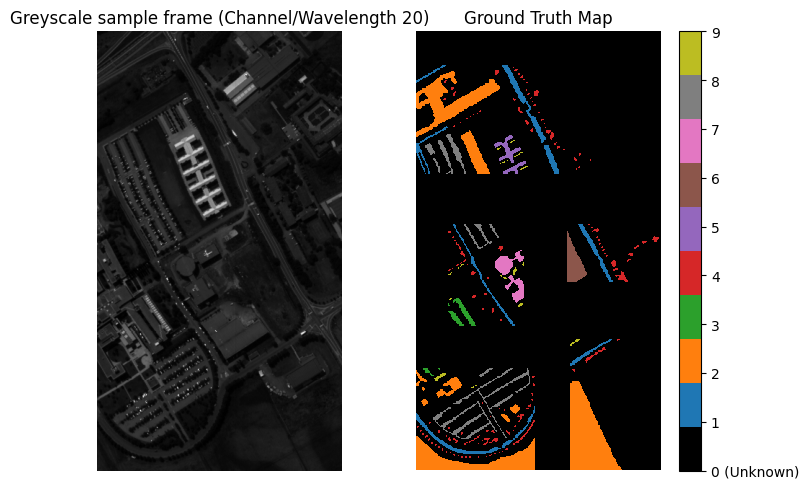


--------------- Class Info ---------------

Class ID  | Count  | Percent (%)
--------------------------------
0         | 182362 | 87.93%
1         | 3526   | 1.70%
2         | 13435  | 6.48%
3         | 522    | 0.25%
4         | 1805   | 0.87%
5         | 647    | 0.31%
6         | 1113   | 0.54%
7         | 1056   | 0.51%
8         | 2617   | 1.26%
9         | 317    | 0.15%
--------------------------------

Total pixels/samples : 207400



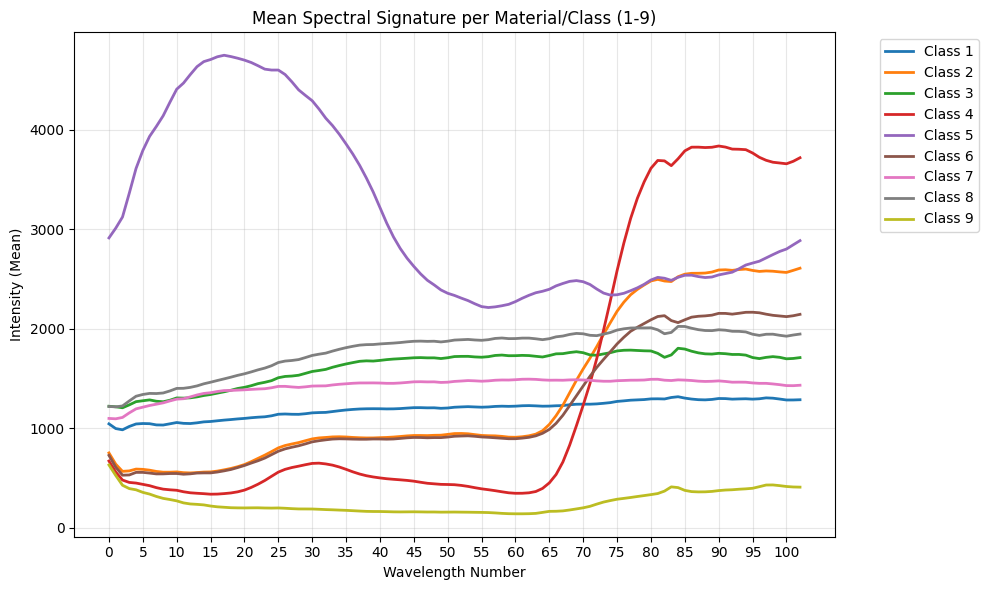


------------------------------------------

--------------- Missing Values ---------------

Missing Values per Feature Table (Descending):
                Missing Count  Percent (%)
Wavelength_0                0          0.0
Wavelength_1                0          0.0
Wavelength_2                0          0.0
Wavelength_3                0          0.0
Wavelength_4                0          0.0
...                       ...          ...
Wavelength_99               0          0.0
Wavelength_100              0          0.0
Wavelength_101              0          0.0
Wavelength_102              0          0.0
Material                    0          0.0

[104 rows x 2 columns]


Missing values of dataframe: 0 / 21569600 -> 0.00%

----------------------------------------------

--------------- Duplicates ---------------

Total dublicate samples: 0

--------------------------------------------------


--------------- Constant Features ---------------

Constant Features List: []

Total constant

In [30]:
sample_channel = 20

class_name = 'Material'
class_colors = ['black'] + sns.color_palette("tab10", 9).as_hex()
class_cmap = ListedColormap(class_colors)


n_samples = Data.shape[0] * Data.shape[1]
n_features = Data.shape[2]

Data_flat = Data.reshape(n_samples, n_features)
Labels_flat = Labels.reshape(n_samples)

feat_names = [f'Wavelength_{i}' for i in range(n_features)]

df = pd.DataFrame(Data_flat, columns=feat_names)
df[class_name] = Labels_flat


print('\n' + 25 * "=" + " Dataset Info " + 25 * "=" + '\n')

print(df.info())
print()

plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
plt.imshow(Data[:, :, sample_channel], cmap='gray')
plt.title(f"Greyscale sample frame (Channel/Wavelength {sample_channel})")
plt.axis('off')

plt.subplot(1, 2, 2)
img = plt.imshow(Labels, cmap=class_cmap, interpolation='nearest')
plt.title("Ground Truth Map")
plt.axis('off')
cbar = plt.colorbar(img, ticks=range(10))
cbar.ax.set_yticklabels(['0 (Unknown)'] + [f'{i}' for i in range(1, 10)])

plt.tight_layout()
plt.show()


print('\n' + 15 * "-" + " Class Info " + 15 * "-" + '\n')

class_counts = df[class_name].value_counts().sort_index()
total_pixels = len(df)

print(f"{'Class ID':<9} | {'Count':<6} | {'Percent (%)':<11}")
print("-" * 32)
for cls, count in class_counts.items():
    percent = (count / total_pixels) * 100
    print(f"{cls:<9} | {count:<6} | {percent:.2f}%")
print("-" * 32)
print(f"\nTotal pixels/samples : {total_pixels}\n")

mean_spectra = df[df[class_name] != 0].groupby(class_name).mean()

plt.figure(figsize=(10, 6))

for cls_id in mean_spectra.index:
    plt.plot(range(n_features), mean_spectra.loc[cls_id],
              label=f'Class {cls_id}', linewidth=2)

plt.title("Mean Spectral Signature per Material/Class (1-9)")
plt.xlabel("Wavelength Number")
plt.ylabel("Intensity (Mean)")
plt.xticks(range(0, n_features, 5))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + 42 * "-")


print('\n' + 15 * "-" + " Missing Values " + 15 * "-" + '\n')

missing_per_feat = df.isnull().sum()
missing_per_feat_percent = (df.isnull().mean() * 100)

missing_feat_table = pd.DataFrame({
    'Missing Count': missing_per_feat,
    'Percent (%)': missing_per_feat_percent
}).sort_values(by='Percent (%)', ascending=False)

print("Missing Values per Feature Table (Descending):")
print(missing_feat_table)
print()

total_cells = df.size
total_missing = missing_per_feat.sum()
percent_missing = (total_missing / total_cells) * 100

print(f"\nMissing values of dataframe: {total_missing} / {total_cells} "
      f"-> {percent_missing:.2f}%")

print('\n' + 46 * "-")


print('\n' + 15 * "-" + " Duplicates " + 15 * "-" + '\n')
dupes_count = df.duplicated().sum()
print(f"Total dublicate samples: {dupes_count}")
print("\n" + 50 * "-" + "\n")


print('\n' + 15 * "-" + " Constant Features " + 15 * "-" + '\n')
constant_feat = [feat for feat in df.columns if df[feat].nunique() <= 1]
print(f"Constant Features List: {constant_feat}")
print(f'\nTotal constant features: {len(constant_feat)}')
print('\n' + 48 * "-")


print('\n' + 15 * "-" + " Quasi-Constant Features " + 15 * "-" + '\n')

quasi_constant_feats = []
for feat in feat_names:

    if feat in constant_feat: continue

    top_val_freq = df[feat].value_counts(normalize=True, dropna=False).values[0]

    if top_val_freq >= 0.99:
        quasi_constant_feats.append(feat)

print(f"Quasi-Constant (>=99% but not 100% of values) Feature List: {quasi_constant_feats}")
print(f'\nTotal quasi-constant features: {len(quasi_constant_feats)}')

print('\n' + 55 * "-")

print('\n' + 64 * "=" + '\n\n')

In [31]:
df_train = df[df[class_name] != 0].copy()


print('\n' + 25 * "=" + " Training Set Info " + 25 * "=" + '\n')

print(f"Original DataFrame shape: {df.shape}")
print(f"Training DataFrame shape: {df_train.shape}\n")

print(df_train.info())

print('\n' + 15 * "-" + " Class Info " + 15 * "-" + '\n')

class_counts_train = df_train[class_name].value_counts().sort_index()
total_pixels_train = len(df_train)

print(f"{'Class ID':<9} | {'Count':<6} | {'Percent (%)':<11}")
print("-" * 32)
for cls, count in class_counts_train.items():
    percent = (count / total_pixels_train) * 100
    print(f"{cls:<9} | {count:<6} | {percent:.2f}%")
print("-" * 32)
print(f"\nTotal pixels/samples : {total_pixels_train}\n")

print('\n' + 42 * "-")


print('\n' + 15 * "-" + " Quasi-Constant Features " + 15 * "-" + '\n')

quasi_constant_feats_train = []
for feat in feat_names:

    top_val_freq = df_train[feat].value_counts(normalize=True, dropna=False).values[0]

    if top_val_freq >= 0.99:
        quasi_constant_feats_train.append(feat)

print(f"Quasi-Constant (>=99% but not 100% of values) Feature List: {quasi_constant_feats_train}")
print(f'\nTotal quasi-constant features: {len(quasi_constant_feats_train)}')

print('\n' + 55 * "-")

print('\n' + 69 * "=" + '\n\n')


========================= Training Set Info =========================

Original DataFrame shape: (207400, 104)
Training DataFrame shape: (25038, 104)

<class 'pandas.core.frame.DataFrame'>
Index: 25038 entries, 16696 to 207345
Columns: 104 entries, Wavelength_0 to Material
dtypes: float64(103), uint8(1)
memory usage: 19.9 MB
None

--------------- Class Info ---------------

Class ID  | Count  | Percent (%)
--------------------------------
1         | 3526   | 14.08%
2         | 13435  | 53.66%
3         | 522    | 2.08%
4         | 1805   | 7.21%
5         | 647    | 2.58%
6         | 1113   | 4.45%
7         | 1056   | 4.22%
8         | 2617   | 10.45%
9         | 317    | 1.27%
--------------------------------

Total pixels/samples : 25038


------------------------------------------

--------------- Quasi-Constant Features ---------------

Quasi-Constant (>=99% but not 100% of values) Feature List: []

Total quasi-constant features: 0

----------------------------------------------

### **Β) Προεπεξεργασία Δεδομένων**

#### **i) Standard Scaling**

In [55]:
df_data = df.drop(columns=[class_name])
df_label = df[class_name]

mean = df_data.mean(axis=0)
std = df_data.std(axis=0)

df_data_n = ((df_data - mean) / std)

print("=== Before Standard Scaling ===\n")
print("Data Feature mean:")
print(mean)
print("\nDate Feature std:")
print(std)

print("\n\n=== After Standard Scaling ===\n")
print("Data Feature mean:")
print(np.round(df_data_n.mean(axis=0),6))
print("\nData Feature std:")
print(df_data_n.std(axis=0))

=== Before Standard Scaling ===

Data Feature mean:
Wavelength_0       925.324995
Wavelength_1       850.237584
Wavelength_2       800.363558
Wavelength_3       809.889783
Wavelength_4       830.085950
                     ...     
Wavelength_98     2238.254364
Wavelength_99     2231.822647
Wavelength_100    2224.744884
Wavelength_101    2236.901707
Wavelength_102    2253.451692
Length: 103, dtype: float64

Date Feature std:
Wavelength_0      444.427499
Wavelength_1      468.464292
Wavelength_2      493.590158
Wavelength_3      527.235307
Wavelength_4      555.419089
                     ...    
Wavelength_98     826.922155
Wavelength_99     827.403828
Wavelength_100    827.257369
Wavelength_101    834.092348
Wavelength_102    844.165146
Length: 103, dtype: float64


=== After Standard Scaling ===

Data Feature mean:
Wavelength_0      0.0
Wavelength_1     -0.0
Wavelength_2      0.0
Wavelength_3     -0.0
Wavelength_4      0.0
                 ... 
Wavelength_98    -0.0
Wavelength_99    

#### **ii) Principal Component Analysis**

In [ ]:
# df_data = df.drop(columns=[class_name])
# df_label = df[class_name]

pca = PCA(n_components=80, random_state=state)
df_data_pca = pca.fit_transform(df_data_n)

print(f"PCA reduced dimensions to: {pca.n_components_}")

PCA reduced dimensions to: 80


### **Γ) Διαχωρισμός Δεδομένων**

In [56]:
val_size = 0.2

X = df_data_n[df[class_name] != 0].copy()
y = df_train[class_name]

# X = df_train[feat_names]
# y = df_train[class_name]

print("\nTraining set before splitting:", X.shape)
print('\n' + 15 * "=" + " Hold-Out Split Info " + 15 * "=" + '\n')

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=val_size,
    stratify=y,
    random_state=state,
    shuffle=True
)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")

train_c_count = y_train.value_counts(normalize=False).sort_index()
val_c_count = y_val.value_counts(normalize=False).sort_index()

train_c_norm = y_train.value_counts(normalize=True).sort_index()
val_c_norm = y_val.value_counts(normalize=True).sort_index()

train_c_percent = [f"{100*count:.2f}%" for count in train_c_norm]
val_c_percent = [f"{100*count:.2f}%" for count in val_c_norm]

print(f"\nTraining class counts:        {train_c_count.values}")
print(f"Training class percentages:   {train_c_percent}")
print(f"\nValidation class counts:      {val_c_count.values}")
print(f"Validation class percentages: {val_c_percent}\n")

print( 51 * "=" + '\n')


Training set before splitting: (25038, 103)

=============== Hold-Out Split Info ===============

Training set:   (20030, 103)
Validation set: (5008, 103)

Training class counts:        [ 2821 10748   418  1444   517   890   845  2093   254]
Training class percentages:   ['14.08%', '53.66%', '2.09%', '7.21%', '2.58%', '4.44%', '4.22%', '10.45%', '1.27%']

Validation class counts:      [ 705 2687  104  361  130  223  211  524   63]
Validation class percentages: ['14.08%', '53.65%', '2.08%', '7.21%', '2.60%', '4.45%', '4.21%', '10.46%', '1.26%']




In [43]:
n_folds = 5

X = df_data_n[df[class_name] != 0].copy()
y = df_train[class_name]

# X = df_train[feat_names]
# y = df_train[class_name]

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=state)

print("\nTraining set before folds:", X.shape)
print('\n' + 15 * "=" + " Fold Info " + 15 * "=" + '\n')

fold_num = 1
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(6 * "-" + f" Fold {fold_num} " + 6 * "-")
    print(f"Training set:   {X_train.shape}")
    print(f"Validation set: {X_val.shape}")

    train_c_count = y_train.value_counts(normalize=False).sort_index()
    val_c_count = y_val.value_counts(normalize=False).sort_index()

    train_c_norm = y_train.value_counts(normalize=True).sort_index()
    val_c_norm = y_val.value_counts(normalize=True).sort_index()

    train_c_percent = [f"{100*count:.2f}%" for count in train_c_norm]
    val_c_percent = [f"{100*count:.2f}%" for count in val_c_norm]

    print(f"\nTraining class counts:        {train_c_count.values}")
    print(f"Training class percentages:   {train_c_percent}")
    print(f"\nValidation class counts:      {val_c_count.values}")
    print(f"Validation class percentages: {val_c_percent}\n\n")

    fold_num += 1

print( 41 * "=" + '\n')


Training set before folds: (25038, 103)

=============== Fold Info ===============

------ Fold 1 ------
Training set:   (20030, 103)
Validation set: (5008, 103)

Training class counts:        [ 2820 10748   418  1444   518   891   844  2094   253]
Training class percentages:   ['14.08%', '53.66%', '2.09%', '7.21%', '2.59%', '4.45%', '4.21%', '10.45%', '1.26%']

Validation class counts:      [ 706 2687  104  361  129  222  212  523   64]
Validation class percentages: ['14.10%', '53.65%', '2.08%', '7.21%', '2.58%', '4.43%', '4.23%', '10.44%', '1.28%']


------ Fold 2 ------
Training set:   (20030, 103)
Validation set: (5008, 103)

Training class counts:        [ 2821 10748   417  1444   518   891   845  2093   253]
Training class percentages:   ['14.08%', '53.66%', '2.08%', '7.21%', '2.59%', '4.45%', '4.22%', '10.45%', '1.26%']

Validation class counts:      [ 705 2687  105  361  129  222  211  524   64]
Validation class percentages: ['14.08%', '53.65%', '2.10%', '7.21%', '2.58%', '4.4

### **Δ) Επιλογή Ταξινομητή**

### **Ε) Βελτιστοποίηση Υπερπαραμέτρων**

#### **i) Αναζήτηση στον χώρο των Υπερπαραμέτρων**

In [70]:
search_pipeline = Pipeline([
    ('clf', SVC(
        kernel='rbf',
        class_weight='balanced',
        cache_size=1000,
        decision_function_shape='ovo',
        random_state=state
    ))
])

X_combined = np.concatenate((X_train, X_val), axis=0)
y_combined = np.concatenate((y_train, y_val), axis=0)


# -1: Training Index
#  0: Validation Index
test_fold = [-1] * len(X_train) + [0] * len(X_val)
ps = PredefinedSplit(test_fold)

print(f"\nTotal samples for searching:   {X_combined.shape[0]}")
print(f"Total Training samples:        {len(X_train)}")
print(f"Total Validation samples:      {len(X_val)}")


Total samples for searching:   25038
Total Training samples:        20030
Total Validation samples:      5008


In [ ]:
param_distributions = {
    'clf__C': reciprocal(0.01, 1000),
    'clf__gamma': reciprocal(0.001, 0.1)
}

random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=ps,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=state,
    verbose=1,
)

random_search.fit(X_combined, y_combined)

best_model_search = random_search.best_estimator_
cv_results = pd.DataFrame(random_search.cv_results_)
sorted_results = cv_results.sort_values(by='rank_test_score')

print("\n" + 10 * "=" + " Random Search Model Ranking " +  10 * "="  + "\n")

for index, row in sorted_results.iterrows():
    print(f"Rank: {row['rank_test_score']}")
    print(f"Score (F1 Macro): {row['mean_test_score']:.4f}")
    print("Parameters:")

    for param, value in row['params'].items():
        print(f"   {param}: {value}")

    print("\n")

print( 49 * "=" + "\n")

print("Random Search Best Model:")
print(best_model_search)
print(f"\nRandom Search Best Params (F1 Macro = {random_search.best_score_:.4f}):")
print(random_search.best_params_)
print()


In [71]:
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100, 1000],
    'clf__gamma': ['scale', 0.1, 0.01, 0.001]
}

grid_search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=param_grid,
    cv=ps,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_combined, y_combined)

best_model_search = grid_search.best_estimator_
results = pd.DataFrame(grid_search.cv_results_)
sorted_results = results.sort_values(by='rank_test_score')

print("\n" + 10 * "=" + " Grid Search Model Ranking " +  10 * "="  + "\n")

for index, row in sorted_results.iterrows():
    print(f"Rank: {row['rank_test_score']}")
    print(f"Score (F1 Macro): {row['mean_test_score']:.4f}")
    print("Parameters:")

    for param, value in row['params'].items():
        print(f"   {param}: {value}")

    print("\n")

print( 47 * "=" + "\n")

print("Grid Search Best Model:")
print(best_model_search)
print(f"\nGrid Search Best Params (F1 Macro = {grid_search.best_score_:.4f}):")
print(grid_search.best_params_)
print()


Fitting 1 folds for each of 24 candidates, totalling 24 fits


KeyboardInterrupt: 

#### **ii) Fine Tuning Υπερπαραμέτρων**

In [57]:
svm_C = 100.0
svm_gamma = 'scale'


fine_tune_pipeline = Pipeline([
    ('classifier', SVC(
        kernel='rbf',
        C=svm_C,
        gamma=svm_gamma,
        class_weight='balanced',
        cache_size=1000,
        decision_function_shape='ovo',
        random_state=state
    ))
])

print("\nModel Training in progress...")
fine_tune_pipeline.fit(X_train, y_train)

y_pred = fine_tune_pipeline.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average='macro')
weighted_f1 = f1_score(y_val, y_pred, average='weighted')
cm = confusion_matrix(y_val, y_pred)

print("\n" + 15 * "=" + " Training Summary " + 15 * "=" + '\n')
print(f"Accuracy:    {accuracy:.2%}")
print(f"Macro F1:    {macro_f1:.2%}")
print(f"Weighted F1: {weighted_f1:.2%}")

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, zero_division=0, digits=4))

print("Confusion Matrix:\n")
print(cm)

print("\n" + 48* "=" + "\n")


Model Training in progress...

=============== Training Summary ===============

Accuracy:    96.07%
Macro F1:    93.26%
Weighted F1: 96.21%

Classification Report:

              precision    recall  f1-score   support

           1     0.9755    0.9617    0.9686       705
           2     0.9954    0.9687    0.9819      2687
           3     0.6333    0.9135    0.7480       104
           4     0.9199    0.9861    0.9519       361
           5     1.0000    1.0000    1.0000       130
           6     0.8007    0.9731    0.8785       223
           7     0.9206    0.9336    0.9271       211
           8     0.9772    0.9008    0.9374       524
           9     1.0000    1.0000    1.0000        63

    accuracy                         0.9607      5008
   macro avg     0.9136    0.9597    0.9326      5008
weighted avg     0.9661    0.9607    0.9621      5008

Confusion Matrix:

[[ 678    0    8    0    0    0   17    2    0]
 [   0 2603    0   31    0   53    0    0    0]
 [   0    0  

In [51]:
svm_C = 100.0
svm_gamma = 'scale'


fine_tune_pipeline = Pipeline([
    ('classifier', SVC(
        kernel='rbf',
        C=svm_C,
        gamma=svm_gamma,
        class_weight='balanced',
        cache_size=1000,
        decision_function_shape='ovo',
        random_state=state
    ))
])

results = {
    'accuracy': [],
    'macro_f1': [],
    'weighted_f1': []
}

print("\nModel Training in progress...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    fine_tune_pipeline.fit(X_train, y_train)

    y_pred = fine_tune_pipeline.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    weighted_f1 = f1_score(y_val, y_pred, average='weighted')
    cm = confusion_matrix(y_val, y_pred)

    results['accuracy'].append(accuracy)
    results['macro_f1'].append(macro_f1)
    results['weighted_f1'].append(weighted_f1)

    print("\n" + 15* "-" + f" Fold {fold+1} " + 15 * "-")
    print(f"\nAccuracy:    {accuracy:.2%}")
    print(f"Macro F1:    {macro_f1:.2%}")
    print(f"Weighted F1: {weighted_f1:.2%}")

    print("\n\nClassification Report:\n")
    print(classification_report(y_val, y_pred, zero_division=0, digits=4))

    print("\nConfusion Matrix:\n")
    print(cm)
    print("\n" + 38 * "-" + '\n')


print("\n" + 15 * "=" + " Training Summary " + 15 * "=" + '\n')
print(f"Average Accuracy:    {np.mean(results['accuracy']):.4f}  (std = {np.std(results['accuracy']):.4f})")
print(f"Average Macro F1:    {np.mean(results['macro_f1']):.4f}  (std = {np.std(results['macro_f1']):.4f})")
print(f"Average Weighted F1: {np.mean(results['weighted_f1']):.4f}  (std = {np.std(results['weighted_f1']):.4f})")
print("\n" + 48* "=" + "\n")



Model Training in progress...


--------------- Fold 1 ---------------

Accuracy:    95.51%
Macro F1:    92.33%
Weighted F1: 95.70%


Classification Report:

              precision    recall  f1-score   support

           1     0.9782    0.9518    0.9648       706
           2     0.9969    0.9639    0.9801      2687
           3     0.5871    0.8750    0.7027       104
           4     0.9273    0.9889    0.9571       361
           5     1.0000    1.0000    1.0000       129
           6     0.7674    0.9955    0.8667       222
           7     0.9050    0.9434    0.9238       212
           8     0.9543    0.8776    0.9143       523
           9     1.0000    1.0000    1.0000        64

    accuracy                         0.9551      5008
   macro avg     0.9018    0.9551    0.9233      5008
weighted avg     0.9623    0.9551    0.9570      5008


Confusion Matrix:

[[ 672    0    6    0    0    1   21    6    0]
 [   0 2590    0   28    0   66    0    3    0]
 [   0    0   91    